In [6]:
# Import required libraries
import pandas as pd
import numpy as np
import pickle

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
# Load dataset from CSV file
df = pd.read_csv("loan_data.csv")

# Display first 5 rows
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
# Information about dataset
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
# Drop unnecessary column (ID)
df.drop("Loan_ID", axis=1, inplace=True)

# Handle missing values

# Fill LoanAmount with mean
df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)

# Fill Credit_History with most frequent value
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill remaining missing values using forward fill
df.fillna(method='ffill', inplace=True)

C:\Users\HP Z Book\AppData\Local\Temp\ipykernel_2348\900478319.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
C:\Users\HP Z Book\AppData\Local\Temp\ipykernel_2348\900478319.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

In [10]:
# Convert categorical values (Male/Female, Yes/No, etc.) into numbers

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,146.412162,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.000000,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.000000,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.000000,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.000000,360.0,1.0,2,1


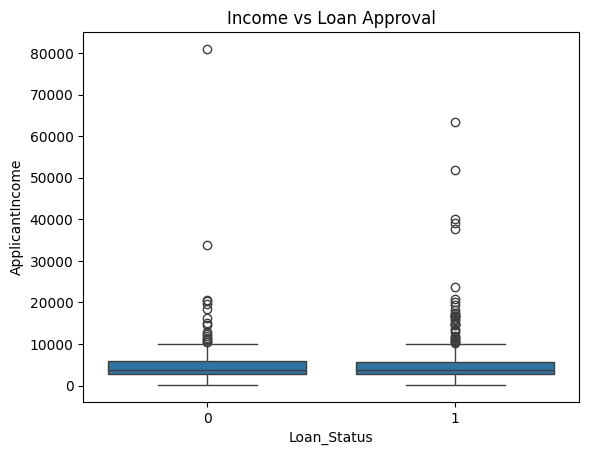

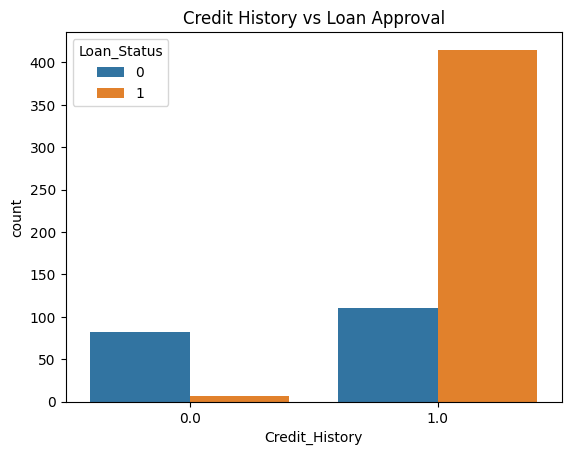

In [11]:
# Income vs Loan Approval
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Income vs Loan Approval")
plt.show()

# Credit History vs Loan Approval
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

In [12]:
# Select important features based on analysis

df = df[['ApplicantIncome','LoanAmount','Credit_History','Education','Loan_Status']]

In [13]:
# Separate input features and output label

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [14]:
# Normalize data to bring all features to same scale

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [15]:
# Split dataset into training and testing data (80-20)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [16]:
# Apply multiple ML models

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

best_model = None
best_accuracy = 0

# Train and evaluate each model
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

    # Select best model
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model


Logistic Regression
Accuracy: 0.7967479674796748
Precision: 0.7830188679245284
Recall: 0.9764705882352941
F1 Score: 0.8691099476439791

Decision Tree
Accuracy: 0.6910569105691057
Precision: 0.7640449438202247
Recall: 0.8
F1 Score: 0.7816091954022989

Random Forest
Accuracy: 0.7804878048780488
Precision: 0.7959183673469388
Recall: 0.9176470588235294
F1 Score: 0.8524590163934426

Naive Bayes
Accuracy: 0.7967479674796748
Precision: 0.7830188679245284
Recall: 0.9764705882352941
F1 Score: 0.8691099476439791

SVM
Accuracy: 0.7967479674796748
Precision: 0.7830188679245284
Recall: 0.9764705882352941
F1 Score: 0.8691099476439791


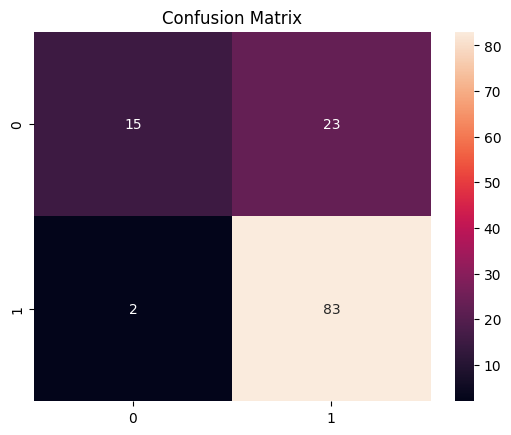

In [17]:
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [18]:
# After training loop ends

print("\nBest Model:", best_model)
print("Best Accuracy:", best_accuracy)

# Save model
import pickle
pickle.dump(best_model, open("model.pkl", "wb"))

print("\nBest model saved!")


Best Model: LogisticRegression()
Best Accuracy: 0.7967479674796748

Best model saved!


In [19]:
print("Loan Approval Prediction System completed successfully!")

Loan Approval Prediction System completed successfully!
